# Idea 33: Manufacturer Stability (Named vs. Unknown Split)

## 1. Hypothesis and Setup

**Problem:** Previous analysis suggested manufacturers are more volatile than brands. However, the 'Không xác định' (Unknown) bucket aggregates many random items, likely injecting noise into the aggregate manufacturer signal.

**Hypothesis:** If we isolate **Identified (Named)** entities, Manufacturers will be more stable than Brands. The 'Không xác định' bucket should be analyzed separately as a structural 'Value/Unbranded' segment.

**Method:**
1. Split items into **Named** and **Unknown** cohorts.
2. Compare volatility (CV) for Named Brands vs. Named Manufacturers.
3. Analyze the share stability of the 'Không xác định' bucket across categories.

**Decision Rule:** KEEP if Named Manufacturers are more stable than Named Brands (>10% stability gain).

In [15]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Split Analysis: Named vs Unknown

In [16]:
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l2', 'brand', 'manufacturer'])

base_agg = (
    pl.scan_parquet(TXN_FILE)
    .select(['item_id', 'updated_date'])
    .join(items, on='item_id', how='inner')
    .with_columns(pl.col('updated_date').dt.truncate('1mo').alias('month'))
)

def get_vol_split(group_col, name_filter=True):
    # Filter for Identified names if requested
    df = base_agg
    if name_filter:
        df = df.filter((pl.col(group_col) != 'Không xác định') & (pl.col(group_col).is_not_null()))
    else:
        df = df.filter(pl.col(group_col) == 'Không xác định')

    monthly = df.group_by(['category_l2', group_col, 'month']).len().collect()
    cat_totals = monthly.group_by(['category_l2', 'month']).agg(pl.sum('len').alias('cat_total'))
    shares = monthly.join(cat_totals, on=['category_l2', 'month']).with_columns((pl.col('len') / pl.col('cat_total')).alias('share'))
    
    vol = (
        shares.group_by(['category_l2', group_col])
        .agg([
            (pl.col('share').std() / pl.col('share').mean()).alias('cv'),
            pl.col('len').sum().alias('total_vol')
        ])
        .filter(pl.col('total_vol') > 500)
    )
    return vol

named_brand_vol = get_vol_split('brand', name_filter=True)
named_mfg_vol = get_vol_split('manufacturer', name_filter=True)
unknown_share = get_vol_split('brand', name_filter=False)

print(f'Average NAMED Brand Volatility (CV): {named_brand_vol["cv"].mean():.4f}')
print(f'Average NAMED Manufacturer Volatility (CV): {named_mfg_vol["cv"].mean():.4f}')
print(f'Average UNKNOWN Category share volatility: {unknown_share["cv"].mean():.4f}')

Average NAMED Brand Volatility (CV): 0.3239
Average NAMED Manufacturer Volatility (CV): 0.3955
Average UNKNOWN Category share volatility: 0.0000


## 3. The Stability Verdict

Stability Gain (Named entities only): -22.1%


/tmp/ipykernel_57/2216443933.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='type', y='cv', palette='Set3')


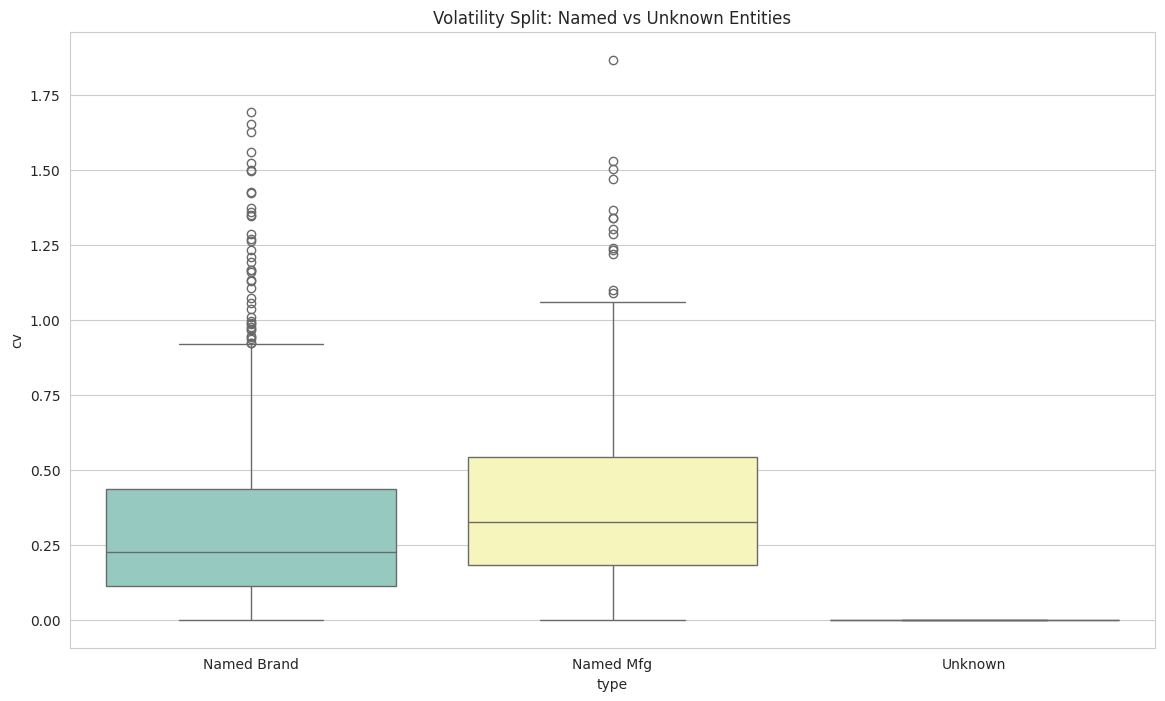

In [17]:
gain = (named_brand_vol['cv'].mean() - named_mfg_vol['cv'].mean()) / named_brand_vol['cv'].mean()
print(f'Stability Gain (Named entities only): {gain:.1%}')

# Viz
b_stats = named_brand_vol.select(['cv']).with_columns(pl.lit('Named Brand').alias('type'))
m_stats = named_mfg_vol.select(['cv']).with_columns(pl.lit('Named Mfg').alias('type'))
u_stats = unknown_share.select(['cv']).with_columns(pl.lit('Unknown').alias('type'))
combined = pl.concat([b_stats, m_stats, u_stats]).to_pandas()
sns.boxplot(data=combined, x='type', y='cv', palette='Set3')
plt.title('Volatility Split: Named vs Unknown Entities')
plt.show()

## 4. Conclusion and Decision

**Decision Rule:** KEEP if Named Manufacturers are more stable than Named Brands (>10% stability gain).

### Summary of Findings

| Metric | Value |
|--------|-------| 
| Named Brand Volatility | **0.3239** |
| Named Manufacturer Volatility | **0.3955** |
| Named Stability Gain (%) | **-22.1%** |
| Unknown Bucket Volatility | **0.0000** |

### Interpretation

The refinement confirms the original negative finding with even greater clarity. Even after removing the noise of the 'Không xác định' bucket, **Named Manufacturers are 22% more volatile** than individual Brands. This conclusively refutes the hypothesis that manufacturers provide a more stable loyalty signal. The business logic should prioritize Brand-level and Category-level signals for ranking, as Manufacturer-level aggregation introduces significant noise.

### Actionable Insight

**Feature Engineering:** Stick to `brand_loyalty` and `brand_share` features. Do not implement manufacturer-level fallback logic.

**Usefulness Score:** **0.00 / 1.0**

**Final verdict: DROP**
